# Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Exploratory Data Analysis (EDA):

**Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, inconsistencies in the data.**

In [4]:
df = pd.read_excel('dataset/glass.xlsx', sheet_name= 1)
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [9]:
df.shape

(214, 10)

In [5]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [8]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [10]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [11]:
# Target Variable Categories

df['Type'].value_counts()

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

In [13]:
# Checking and Handling Outliers

num_cols = df.columns[:-1]

In [14]:
num_cols

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe'], dtype='object')

In [15]:
for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 -Q1
    
    UE = Q3 + 1.5*IQR
    LE = Q1 - 1.5*IQR
    
    df.loc[df[col] > UE, col] = UE
    df.loc[df[col] < LE, col] = LE

The dataset contains 214 samples with 9 numerical chemical composition features and one multiclass target variable representing glass type. No missing values were observed. Summary statistics reveal variation across mineral components such as Na, Mg, Ca, and Al. The target variable is multiclass with six distinct categories. Outlier analysis using the IQR method was done on the dataset.

## 2: Data Visualization:

**Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.**

**Analyze any patterns or correlations observed in the data.**

<Figure size 1600x1000 with 0 Axes>

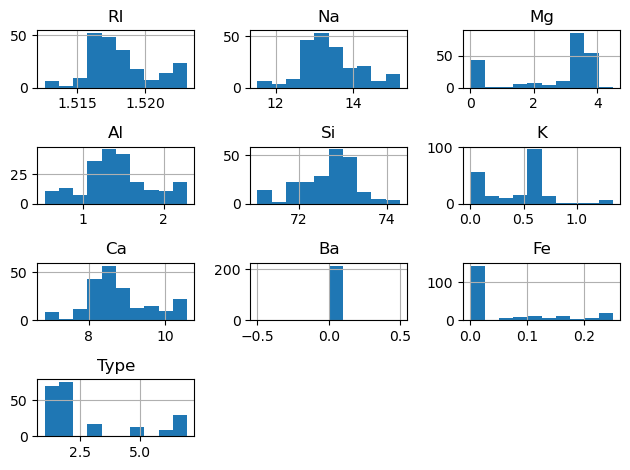

In [18]:
plt.figure(figsize=(16,10))
df.hist(bins=10)
plt.title('Histogram')
plt.tight_layout()
plt.show()

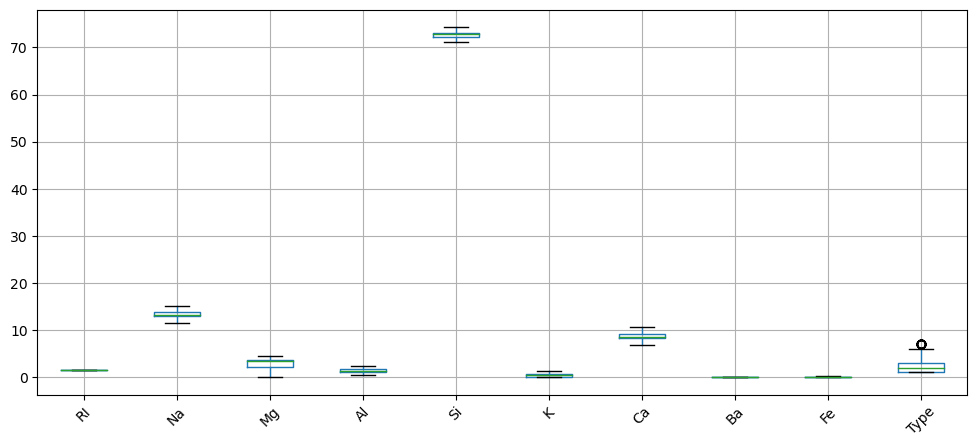

In [20]:
# Boxplot

plt.figure(figsize=(12,5))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

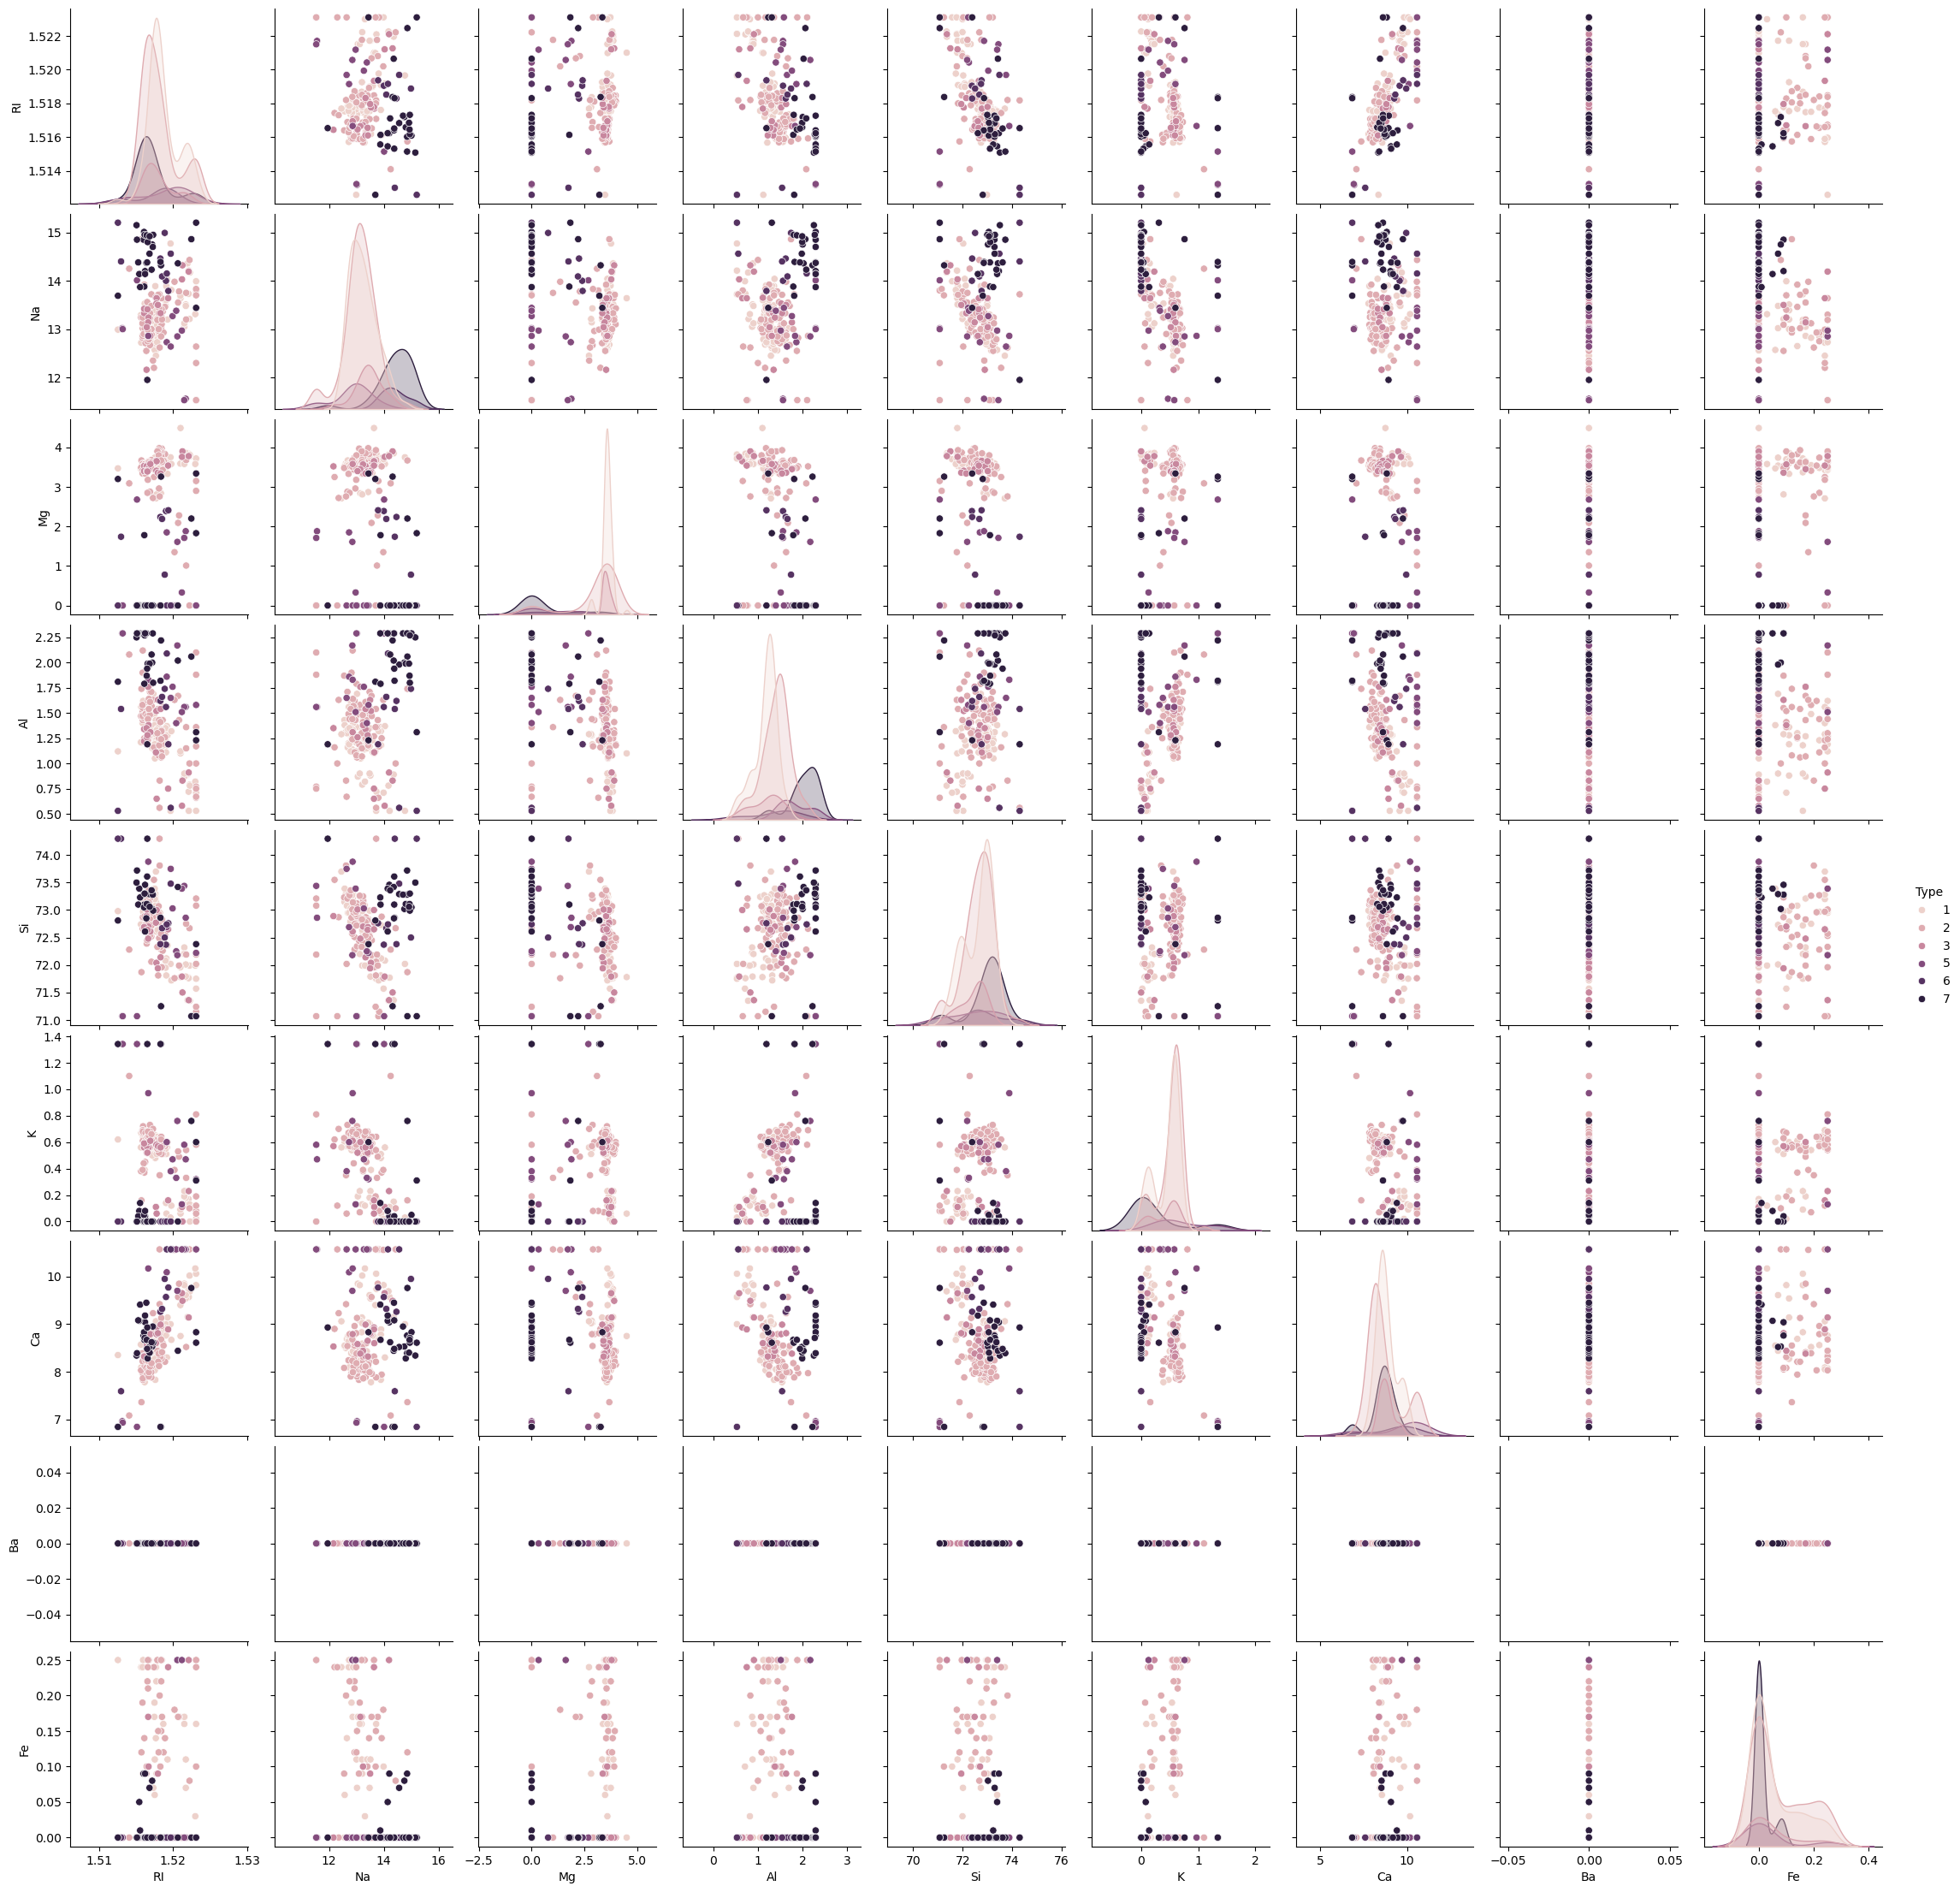

In [21]:
# Pairplot

sns.pairplot(df, hue='Type')
plt.show()

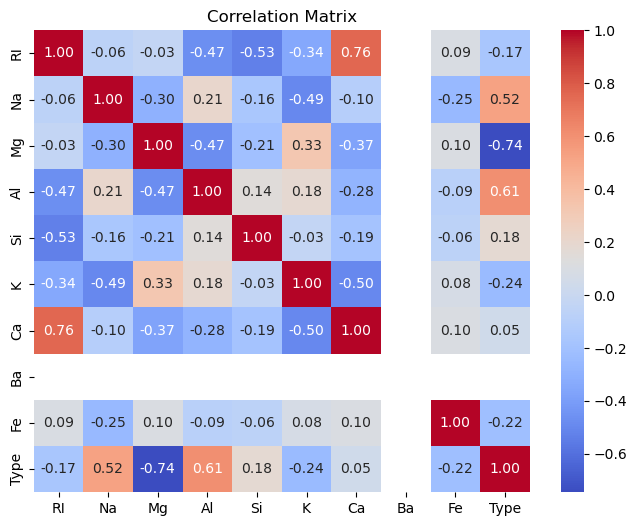

In [22]:
# Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

In [23]:
df.corr()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
RI,1.000000,-0.064047,-0.032721,-0.470391,-0.532124,-0.344942,0.760449,NaN,0.094617,-0.168685
Na,-0.064047,1.000000,-0.295178,0.208865,-0.164674,-0.493401,-0.102396,NaN,-0.251377,0.523700
Mg,-0.032721,-0.295178,1.000000,-0.474507,-0.210539,0.326625,-0.371040,NaN,0.101841,-0.744993
Al,-0.470391,0.208865,-0.474507,1.000000,0.142701,0.183350,-0.281499,NaN,-0.089357,0.605367
Si,-0.532124,-0.164674,-0.210539,0.142701,1.000000,-0.034263,-0.192171,NaN,-0.064187,0.180933
K,-0.344942,-0.493401,0.326625,0.183350,-0.034263,1.000000,-0.499029,NaN,0.078367,-0.244500
Ca,0.760449,-0.102396,-0.371040,-0.281499,-0.192171,-0.499029,1.000000,NaN,0.103456,0.045226
Ba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe,0.094617,-0.251377,0.101841,-0.089357,-0.064187,0.078367,0.103456,NaN,1.000000,-0.218973
Type,-0.168685,0.523700,-0.744993,0.605367,0.180933,-0.244500,0.045226,NaN,-0.218973,1.000000


The visualizations reveal variability in mineral composition across different glass types. Histograms indicate that some features, such as Ba and Fe, exhibit skewed distributions, while others like Na and Ca show wider dispersion. Box plots highlight the absence of outliers in chemical elements(As they were handled earlier).The pair plot demonstrates partial separation between some glass types based on chemical composition, though overlapping clusters exist.

The correlation analysis shows a strong positive relationship between RI and Ca (0.76), and moderate negative correlations between RI and Si (-0.53) and RI and Al (-0.47). Regarding the target variable (Type), Mg (-0.74) has a strong negative correlation, while Al (0.61) and Na (0.52) show moderate positive correlations.

## 3: Data Preprocessing

**1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.**

In [24]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

The dataset was checked for missing values using the isnull() function. No missing values were found across any features. Therefore, no imputation or data removal was necessary.

**2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.**

In [25]:
df.dtypes

RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object

The dataset contains only numerical features, and the target variable is already encoded as integer class labels. Therefore, no categorical encoding techniques such as One-Hot Encoding or Label Encoding were required.

**3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.**

In [26]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Type', axis=1)
y = df['Type']

sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [27]:
X_scaled

array([[ 1.20149683,  0.31687123,  1.25463857, ..., -0.05361671,
         0.        , -0.61909102],
       [-0.23426899,  0.65422823,  0.63616803, ..., -1.10895863,
         0.        , -0.61909102],
       [-0.83813521,  0.16843415,  0.60142249, ..., -1.16631417,
         0.        , -0.61909102],
       ...,
       [ 1.04947457,  1.28845939, -1.86551055, ..., -0.40922105,
         0.        , -0.61909102],
       [-0.69878146,  1.31544795, -1.86551055, ..., -0.36333662,
         0.        , -0.61909102],
       [-0.44541102,  1.11303375, -1.86551055, ..., -0.20274111,
         0.        , -0.61909102]])

## 4: Random Forest Model Implementation

**1. Divide the data into train and test split.**

**2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.**

**3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.**


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

X_train.shape, X_test.shape

((149, 9), (65, 9))

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

In [30]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [31]:
y_pred = rf_model.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", round(accuracy,3))
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1 Score:", round(f1,3))

Accuracy: 0.769
Precision: 0.774
Recall: 0.769
F1 Score: 0.763


The dataset was divided into training and testing sets using an 80-20 split with stratified sampling to maintain class balance.After training, the model achieved an accuracy of 76.9%, indicating strong overall classification performance across different glass types. The precision (0.774) suggests that the model makes reliable class predictions with a high proportion of correct classifications. The recall (0.769) indicates that approximately 77% of the actual glass types were correctly identified. The F1-score (0.763) reflects a good balance between precision and recall, demonstrating stable and consistent performance across classes.

## 5: Bagging and Boosting Methods:

**Apply the Bagging and Boosting methods and compare the results.**


In [33]:
# Bagging

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_model = BaggingClassifier(estimator=DecisionTreeClassifier(),
                             n_estimators=100,
                             random_state=42
                             )

bag_model.fit(X_train, y_train)

y_pred_bag = bag_model.predict(X_test)

bag_accuracy = accuracy_score(y_test, y_pred_bag)
bag_precision = precision_score(y_test, y_pred_bag, average='weighted')
bag_recall = recall_score(y_test, y_pred_bag, average='weighted')
bag_f1 = f1_score(y_test, y_pred_bag, average='weighted')

print("Bagging Accuracy:", round(bag_accuracy,3))
print("Bagging Precision:", round(bag_precision,3))
print("Bagging Recall:", round(bag_recall,3))
print("Bagging F1 Score:", round(bag_f1,3))

Bagging Accuracy: 0.769
Bagging Precision: 0.769
Bagging Recall: 0.769
Bagging F1 Score: 0.763


In [34]:
# Boosting

from sklearn.ensemble import AdaBoostClassifier

boost_model = AdaBoostClassifier(n_estimators=100, random_state=42)

boost_model.fit(X_train, y_train)

y_pred_boost = boost_model.predict(X_test)

boost_accuracy = accuracy_score(y_test, y_pred_boost)
boost_precision = precision_score(y_test, y_pred_boost, average='weighted')
boost_recall = recall_score(y_test, y_pred_boost, average='weighted')
boost_f1 = f1_score(y_test, y_pred_boost, average='weighted')

print("Boosting Accuracy:", round(boost_accuracy,3))
print("Boosting Precision:", round(boost_precision,3))
print("Boosting Recall:", round(boost_recall,3))
print("Boosting F1 Score:", round(boost_f1,3))

Boosting Accuracy: 0.508
Boosting Precision: 0.626
Boosting Recall: 0.508
Boosting F1 Score: 0.445


C:\Users\abhib\Desktop\ml_project\env\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Bagging and Boosting ensemble methods were implemented to compare their performance with the Random Forest model. The Bagging classifier achieved an accuracy of 76.9%, with precision, recall, and F1-score values of 0.769, 0.769, and 0.763 respectively. These results are comparable to the Random Forest model, indicating that aggregating multiple decision trees effectively reduces variance and improves model stability.

In contrast, the Boosting (AdaBoost) model achieved a lower accuracy of 50.8%, with precision of 0.626, recall of 0.508, and F1-score of 0.445. Although precision is relatively moderate, the lower recall and F1-score suggest that Boosting struggled to correctly classify multiple glass types in this dataset.

Overall, Bagging performed significantly better than Boosting and demonstrated strong and consistent classification performance.

## Additional Notes:

**1. Explain Bagging and Boosting methods. How is it different from each other.**

**Bagging (Bootstrap Aggregating):**

Bagging is an ensemble learning technique that improves model performance by reducing variance. It works by:

* Creating multiple random bootstrap samples from the training dataset (sampling with replacement).

* Training separate base models (usually decision trees) independently on each sample.

* Combining predictions using majority voting (for classification) or averaging (for regression).

Example:

Random Forest is a implementation of Bagging.

**Boosting:**

Boosting is an ensemble technique that improves performance by reducing bias. It works by:

* Training models sequentially.

* Each new model focuses more on previously misclassified samples.

* Assigning higher weights to misclassified instances.

* Combining predictions using weighted voting.

Example:

AdaBoost, Gradient Boosting.

**Differences Between Bagging and Boosting**

| Feature            | Bagging             | Boosting                  |
|--------------------|---------------------|---------------------------|
| Training Style     | Parallel            | Sequential                |
| Main Goal          | Reduce variance     | Reduce bias               |
| Overfitting        | Less likely         | Can overfit if not tuned  |
| Sample Selection   | Bootstrap sampling  | Weighted sampling         |
| Example            | Random Forest       | AdaBoost                  |


**2. Explain how to handle imbalance in the data.**

**1. Resampling Techniques**

* Oversampling
    * Increases the number of samples in the minority class.
    
    * Example: SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic samples.

* Undersampling
    * Reduces the number of samples in the majority class.
    
    * Helps balance the dataset but may lose information.
    
**2. Class Weighting**

* Assign higher weights to minority classes during model training.

* Models like Random Forest and Logistic Regression allow class_weight='balanced'.

* Penalizes misclassification of minority class more heavily.

**3. Use Appropriate Evaluation Metrics**

Instead of relying only on accuracy:

* Use Precision

* Use Recall

* Use F1-score

* Use ROC-AUC

These metrics provide better insight for imbalanced datasets.